<a href="https://colab.research.google.com/github/AnastasijaTashkova/ABS_project_1.0/blob/main/adult_income_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adult Income Dataset Analysis and Classification


## 1. Import Libraries

In [237]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score


## 2. Load Dataset

In [238]:
df = pd.read_csv('adult.csv', na_values='?')
#df = pd.read_csv('adult.csv')
df.sample(10)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
13511,63,Local-gov,382882,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
11540,35,Local-gov,225544,Bachelors,13,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,48,United-States,<=50K
30511,62,Local-gov,33365,HS-grad,9,Widowed,Other-service,Not-in-family,White,Female,0,0,40,Canada,<=50K
22989,46,Self-emp-inc,214627,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,60,United-States,>50K
16967,66,NaN,149422,7th-8th,4,Never-married,NaN,Not-in-family,White,Male,0,0,4,United-States,<=50K
10146,35,State-gov,210866,HS-grad,9,Married-civ-spouse,Other-service,Husband,White,Male,0,0,40,United-States,<=50K
2884,29,Private,255476,5th-6th,3,Never-married,Other-service,Other-relative,White,Male,0,0,35,Mexico,<=50K
14502,60,Private,247483,Some-college,10,Divorced,Exec-managerial,Not-in-family,White,Male,0,0,40,United-States,<=50K
14424,37,NaN,111268,Assoc-voc,11,Never-married,NaN,Own-child,White,Female,0,0,32,United-States,<=50K
8748,26,Private,488459,Some-college,10,Never-married,Exec-managerial,Not-in-family,White,Female,0,0,40,United-States,<=50K


## 3. Dataset Overview

In [239]:
print(df.shape)


(48842, 15)


In [240]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        46043 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       46033 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   47985 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [241]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [242]:
df.isna().sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,2809
relationship,0
race,0
gender,0


In [243]:
df["native-country"].value_counts()

,count
native-country,
United-States,43832
Mexico,951
Philippines,295
Germany,206
Puerto-Rico,184
Canada,182
El-Salvador,155
India,151
Cuba,138


In [244]:
# encode target
df["income"] = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

## 5. Visualizations

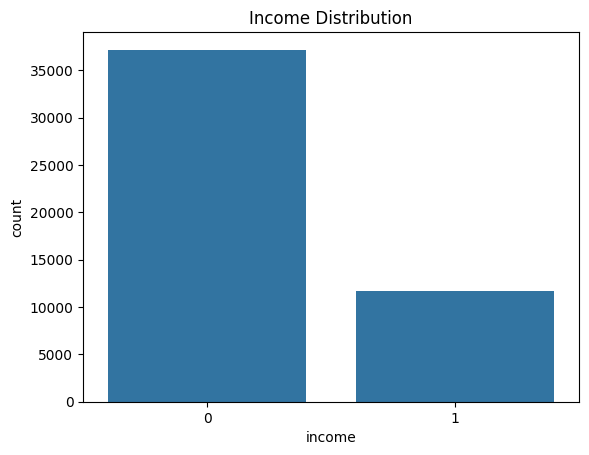

In [245]:
sns.countplot(x='income', data=df)
plt.title('Income Distribution')
plt.show()

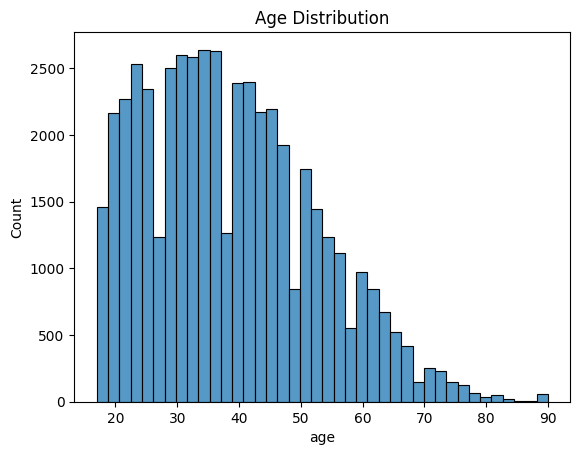

In [246]:
sns.histplot(df['age'], bins=40)
plt.title('Age Distribution')
plt.show()

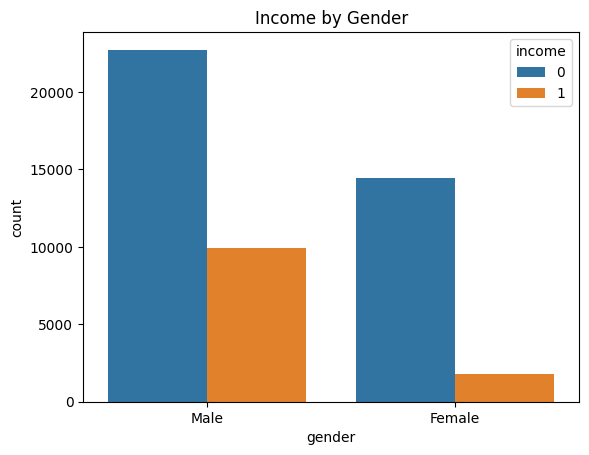

In [247]:
sns.countplot(x='gender', hue='income', data=df)
plt.title('Income by Gender')
plt.show()

In [248]:
df["fnlwgt"].corr(df["income"])

np.float64(-0.006338859530113214)

## 4. Data Cleaning

In [249]:
df.isna().sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,2809
relationship,0
race,0
gender,0


In [250]:
print((df.isna().sum() / len(df)) * 100)

age                0.000000
workclass          5.730724
fnlwgt             0.000000
education          0.000000
educational-num    0.000000
marital-status     0.000000
occupation         5.751198
relationship       0.000000
race               0.000000
gender             0.000000
capital-gain       0.000000
capital-loss       0.000000
hours-per-week     0.000000
native-country     1.754637
income             0.000000
dtype: float64


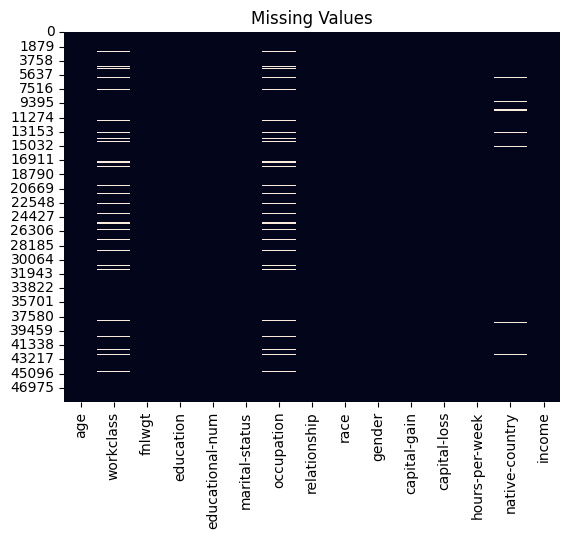

In [251]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isna(), cbar=False)
plt.title("Missing Values")
plt.show()

In [252]:
df = df.drop(columns=['fnlwgt','education'], errors='ignore')

df = df.dropna()

df.head()

,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
5,34,Private,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,0


## 6. Encode Categorical Variables

In [253]:
from sklearn.preprocessing import LabelEncoder

cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

df.head()

,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,2,7,4,6,3,2,1,0,0,40,38,0
1,38,2,9,2,4,0,4,1,0,0,50,38,0
2,28,1,12,2,10,0,4,1,0,0,40,38,1
3,44,2,10,2,6,0,2,1,7688,0,40,38,1
5,34,2,6,4,7,1,4,1,0,0,30,38,0


## 7. Train/Test Split

In [254]:
X = df.drop('income', axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 8. Train Models

In [255]:
# Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)

# LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
lda_pred = lda.predict(X_test)

# QDA
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)
qda_pred = qda.predict(X_test)

## 9. Model Comparison

In [256]:
print('Naive Bayes Accuracy:', accuracy_score(y_test, nb_pred))
print('LDA Accuracy:', accuracy_score(y_test, lda_pred))
print('QDA Accuracy:', accuracy_score(y_test, qda_pred))

Naive Bayes Accuracy: 0.7952459922609176
LDA Accuracy: 0.8131564400221116
QDA Accuracy: 0.7970149253731343


# 1.1 One hot encoding dataset

In [257]:
df_ohe = pd.read_csv('adult.csv', na_values='?')

In [258]:
df_ohe = df_ohe.drop(columns=['fnlwgt','education'], errors='ignore')

df_ohe = df_ohe.dropna()

df_ohe.head()

,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,34,Private,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K


In [259]:
cat_cols = df_ohe.select_dtypes(include="object").columns
print(cat_cols)

Index(['workclass', 'marital-status', 'occupation', 'relationship', 'race',
       'gender', 'native-country', 'income'],
      dtype='object')


In [260]:
y_ohe = df_ohe["income"]
X_ohe = df_ohe.drop("income", axis=1)

In [261]:
X_ohe = pd.get_dummies(X_ohe, columns=cat_cols.drop("income", errors="ignore"), drop_first=True)

In [262]:
y_ohe = y_ohe.map({
    "<=50K":0,
    ">50K":1
})

In [263]:
X_ohe_train, X_ohe_test, y_ohe_train, y_ohe_test = train_test_split(
    X_ohe, y_ohe, test_size=0.2, random_state=42
)

In [264]:
# Naive Bayes
nb = GaussianNB()
nb.fit(X_ohe_train, y_ohe_train)
nb_pred = nb.predict(X_ohe_test)

# LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_ohe_train, y_ohe_train)
lda_pred = lda.predict(X_ohe_test)

# QDA
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_ohe_train, y_ohe_train)
qda_pred = qda.predict(X_ohe_test)

/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


In [265]:
print('Naive Bayes Accuracy:', accuracy_score(y_ohe_test, nb_pred))
print('LDA Accuracy:', accuracy_score(y_ohe_test, lda_pred))
print('QDA Accuracy:', accuracy_score(y_ohe_test, qda_pred))

Naive Bayes Accuracy: 0.8180210060807076
LDA Accuracy: 0.8399115533443892
QDA Accuracy: 0.4619126589275843


2. Why Naive Bayes and LDA Improved

Naive Bayes:

One-hot encoding turns categorical features into binary independent features.

NB assumes feature independence, so now this assumption fits better.

Accuracy increased from 79.5% → 81.8%.

LDA:

One-hot encoding preserves numeric representation and avoids artificial ordering (like with label encoding).

Linear boundaries can now separate classes more cleanly.

Accuracy increased from 81.3% → 84%.

✅ Both improvements make sense.

3. Why QDA Collapsed

QDA assumes each class has its own covariance matrix.

One-hot encoding produces very sparse features (mostly 0s and 1s).

Sparse binary features make covariance matrices nearly singular → QDA cannot estimate them reliably.

Result: accuracy drops dramatically (~46%).

⚠️ This is a known problem: QDA struggles with high-dimensional sparse binary data.

## 10. Conclusion

Compare the accuracies and explain results based on model assumptions:

- Naive Bayes assumes feature independence.
- LDA assumes linear decision boundaries and shared covariance.
- QDA allows different covariance matrices for each class.

2. Why LDA Wins

LDA assumes linear separation between classes and that all classes share the same covariance matrix.

In the Adult dataset, the features like education_num, age, hours_per_week and encoded categorical variables create approximately linear boundaries, so LDA can model them efficiently.

LDA benefits from numeric features being roughly continuous, which fits well after proper encoding.

3. Why Naive Bayes is Slightly Lower

Naive Bayes assumes independence among features.

In reality, some features are correlated (e.g., education_num and occupation), so the independence assumption is violated.

Despite this, NB is still robust, which is why it achieves ~79.5%.

4. Why QDA is Slightly Lower

QDA allows different covariance matrices per class, which adds flexibility.

But this also means more parameters to estimate.

With the Adult dataset, the dataset is large enough, but the extra flexibility overfits slightly, reducing accuracy compared to LDA.

5. Key Takeaways

LDA is best here because the dataset roughly satisfies its assumptions.

Naive Bayes is competitive but limited by correlated features.

QDA is more flexible but slightly overfits.